In [665]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import roc_curve, roc_auc_score

In [666]:
df = pd.read_csv('/kaggle/input/datasets/samvelgalstyan/loanpay/train.csv')

In [667]:
df

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
593989,593989,23004.26,0.152,703,20958.37,10.92,Female,Single,High School,Employed,Business,C3,1.0
593990,593990,35289.43,0.105,559,3257.24,14.62,Male,Single,Bachelor's,Employed,Debt consolidation,F5,1.0
593991,593991,47112.64,0.072,675,929.27,14.13,Female,Married,Bachelor's,Employed,Debt consolidation,C1,1.0
593992,593992,76748.44,0.067,740,16290.40,9.87,Male,Single,Bachelor's,Employed,Debt consolidation,B2,1.0


In [668]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 58.9+ MB


In [669]:
df = df.drop('id',axis=1)

In [670]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [671]:
encoder.set_output(transform='pandas')

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [672]:
str_cols = df.select_dtypes('object').columns
num_cols = df.select_dtypes(['int','float']).columns
df_str = encoder.fit_transform(df[str_cols])
df_num = df[num_cols]

In [673]:
df_train = pd.concat([df_str,df_num],axis=1,)

In [674]:
X = df_train.drop('loan_paid_back',axis=1)
y = df_train['loan_paid_back']

In [675]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [676]:
binary_cols = []
for i in X_train.columns:
    if X_train[i].nunique() <=2 and set(X_train[i]).issubset({0,1}):
        binary_cols.append(i)
num_cols = []
for i in X_train.columns:
    if i not in binary_cols:
        num_cols.append(i)

In [677]:
scaler = StandardScaler()
scaler.set_output(transform='pandas')
X_scale_train = scaler.fit_transform(X_train[num_cols])
X_scale_test = scaler.transform(X_test[num_cols])
X_noscale_train = X_train[binary_cols]
X_noscale_test = X_test[binary_cols]
X_main_train = pd.concat([X_scale_train,X_noscale_train], axis=1, ignore_index=False)
X_main_test = pd.concat([X_scale_test ,X_noscale_test], axis=1, ignore_index=False)

In [678]:
model = LogisticRegressionCV(max_iter=500, class_weight='balanced', cv=5, Cs=[0.01,0.1,1,10], scoring='roc_auc', n_jobs=-1, random_state=42)

In [679]:
model.fit(X_main_train,y_train)

LogisticRegressionCV(Cs=[0.01, 0.1, 1, 10], class_weight='balanced', cv=5,
                     max_iter=500, n_jobs=-1, random_state=42,
                     scoring='roc_auc')

In [680]:
y_proba = model.predict_proba(X_main_test)[:,1]

In [690]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

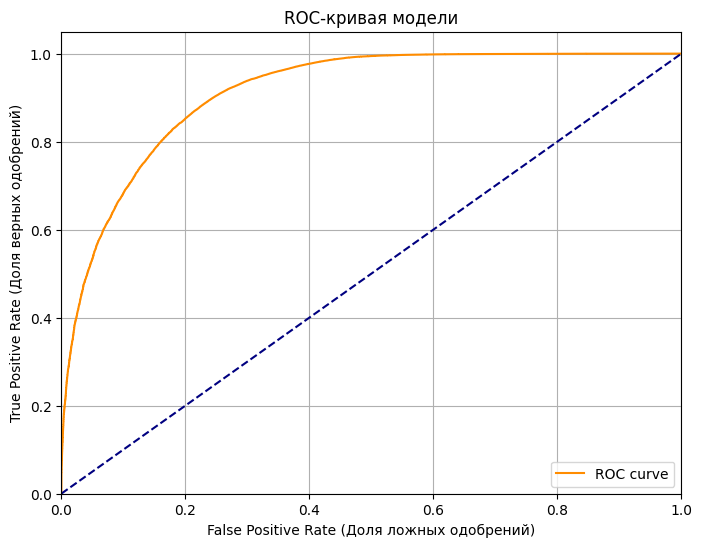

In [691]:
plt.figure(figsize=(8, 6))
plt.plot(fpr,tpr, color='darkorange', label=f'ROC curve')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--') 
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Доля ложных одобрений)')
plt.ylabel('True Positive Rate (Доля верных одобрений)')
plt.title('ROC-кривая модели')
plt.legend(loc="lower right")
plt.grid(True)

In [692]:
youden_index = tpr - fpr
best_index = np.argmax(youden_index)
best_threshold = thresholds[best_index]

In [693]:
y_pred = (y_proba > best_threshold).astype(int)

In [694]:
accuracy_score(y_test, y_pred)

0.8631301610282914

In [695]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.63      0.77      0.69     23997
         1.0       0.94      0.89      0.91     94802

    accuracy                           0.86    118799
   macro avg       0.79      0.83      0.80    118799
weighted avg       0.88      0.86      0.87    118799



In [688]:
confusion_matrix(y_test, y_pred)

array([[18451,  5546],
       [10714, 84088]])

<Axes: >

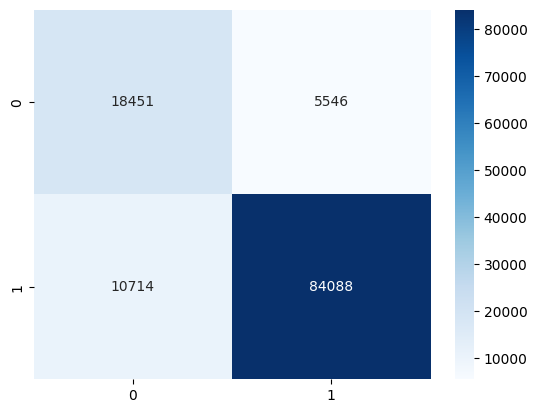

In [689]:
sns.heatmap(confusion_matrix(y_test, y_pred), cmap='Blues', annot=True, fmt='d')